# Imports

In [ ]:
!pip install torchmetrics
!pip install -U "torchmetrics[image]"

In [ ]:
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import os, math, time
from PIL import Image
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, utils
from torchvision.utils import make_grid, save_image
from torchmetrics.image.fid import FrechetInceptionDistance

In [ ]:
RUN_WGAN        = True
RUN_WGAN_CONCAT = True
RUN_WGAN_INJECT = True

GLOBAL_SEED = 42

In [4]:
import json, random

def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def get_rng_state():
    state = {
        "python": random.getstate(),
        "numpy": np.random.get_state(),
        "torch": torch.get_rng_state(),
    }
    if torch.cuda.is_available():
        state["cuda"] = torch.cuda.get_rng_state_all()
    return state

def set_rng_state(state):
    if state is None:
        return
    try:
        random.setstate(state["python"])
        np.random.set_state(state["numpy"])
        torch.set_rng_state(state["torch"])
        if torch.cuda.is_available() and "cuda" in state:
            torch.cuda.set_rng_state_all(state["cuda"])
    except Exception as e:
        print("⚠️ Could not fully restore RNG state:", e)

def optimizer_to(opt, device):
    for state in opt.state.values():
        for k, v in state.items():
            if torch.is_tensor(v):
                state[k] = v.to(device)

def ckpt_paths(ckpt_dir):
    return {
        "last": os.path.join(ckpt_dir, "last.pt"),
        "best": os.path.join(ckpt_dir, "best.pt"),
        "history": os.path.join(ckpt_dir, "history.json"),
    }

def load_history(ckpt_dir):
    p = ckpt_paths(ckpt_dir)["history"]
    if os.path.exists(p):
        with open(p, "r") as f:
            return json.load(f)
    return {"g_losses": [], "d_losses": [], "fid_scores": [], "fid_epochs": []}

def save_history(ckpt_dir, history):
    p = ckpt_paths(ckpt_dir)["history"]
    with open(p, "w") as f:
        json.dump(history, f)

def save_ckpt(path, payload):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save(payload, path)

def try_load_latest_ckpt(G, D, optG, optD, ckpt_dir, device):
    paths = ckpt_paths(ckpt_dir)
    ckpt_path = paths["last"] if os.path.exists(paths["last"]) else (paths["best"] if os.path.exists(paths["best"]) else None)
    if ckpt_path is None:
        return None

    ckpt = torch.load(ckpt_path, map_location=device)
    G.load_state_dict(ckpt["G_state"])
    D.load_state_dict(ckpt["D_state"])
    optG.load_state_dict(ckpt["optG"])
    optD.load_state_dict(ckpt["optD"])
    optimizer_to(optG, device)
    optimizer_to(optD, device)

    set_rng_state(ckpt.get("rng_state", None))

    print(f"✅ Loaded checkpoint: {ckpt_path}")
    return ckpt


# PHASE 1

# Dataset

In [5]:
class CelebABlackBrown(Dataset):
    def __init__(self, root="/kaggle/input/datasets/jessicali9530/celeba-dataset",
                 split="train", transform=None, seed=42):
        super().__init__()
        self.transform = transform

        self.img_dir = os.path.join(root, "img_align_celeba", "img_align_celeba")

        attrs = pd.read_csv(os.path.join(root, "list_attr_celeba.csv"))
        parts = pd.read_csv(os.path.join(root, "list_eval_partition.csv"))
        df = attrs.merge(parts, on="image_id")

        split_id = {"train": 0, "valid": 1, "test": 2}[split]
        df = df[df["partition"] == split_id].reset_index(drop=True)

        black = (df["Black_Hair"] == 1)
        brown = (df["Brown_Hair"] == 1)

        black_only = df.index[black & ~brown].to_numpy()
        brown_only = df.index[brown & ~black].to_numpy()

        g = torch.Generator().manual_seed(seed)
        n = int(min(len(black_only), len(brown_only)))

        black_sel = black_only[torch.randperm(len(black_only), generator=g)[:n].tolist()]
        brown_sel = brown_only[torch.randperm(len(brown_only), generator=g)[:n].tolist()]

        chosen = np.concatenate([black_sel, brown_sel])
        chosen = chosen[torch.randperm(len(chosen), generator=g).tolist()]

        self.df = df.loc[chosen].reset_index(drop=True)

        self.total_black = int((self.df["Black_Hair"] == 1).sum())
        self.total_brown = int((self.df["Brown_Hair"] == 1).sum())

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        img_path = os.path.join(self.img_dir, row["image_id"])
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        c = torch.tensor([
            1.0 if row["Black_Hair"] == 1 else 0.0,
            1.0 if row["Brown_Hair"] == 1 else 0.0,
        ], dtype=torch.float32)

        return img, c

# Transform

In [6]:
transform = transforms.Compose([
    transforms.CenterCrop(178),
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,)*3, (0.5,)*3),
])

# Train Data

In [7]:
batch_size = 64

In [8]:
kaggle_root = "/kaggle/input/datasets/jessicali9530/celeba-dataset"
train_dataset = CelebABlackBrown(root=kaggle_root, split="train", transform=transform, seed=42)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    drop_last=True
)

# Statistics

In [9]:
print("Dataset size:", len(train_dataset))
print("Total Brown positives:", train_dataset.total_brown)
print("Total Black positives:", train_dataset.total_black)
print("Equal:", train_dataset.total_brown == train_dataset.total_black)

Dataset size: 64522
Total Brown positives: 32261
Total Black positives: 32261
Equal: True


In [10]:
attr_names = [c for c in train_dataset.df.columns if c not in ["image_id", "partition"]]
print(len(attr_names))
print(attr_names)

40
['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace', 'Wearing_Necktie', 'Young']


In [11]:
attr_cols = [c for c in train_dataset.df.columns if c not in ["image_id", "partition"]]
vals = train_dataset.df[attr_cols].to_numpy().reshape(-1)
print("Global unique values in attrs:", sorted(np.unique(vals).tolist()))

Global unique values in attrs: [-1, 1]


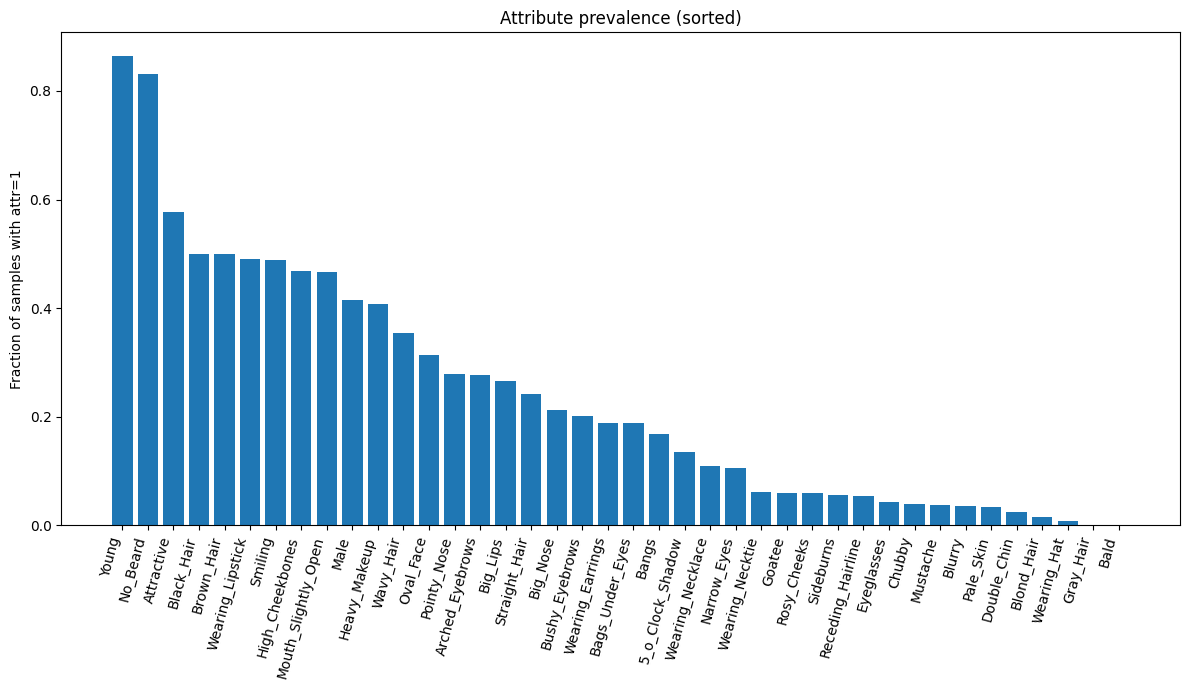

In [12]:
attr_cols = [c for c in train_dataset.df.columns if c not in ["image_id", "partition"]]

A = train_dataset.df[attr_cols].to_numpy()
A01 = (A == 1).astype(np.float32)

pos_rate = A01.mean(axis=0)
pos_count = A01.sum(axis=0).astype(int)
names = attr_cols

order = np.argsort(pos_rate)[::-1]
pos_rate_sorted = pos_rate[order]
names_sorted = [names[i] for i in order]

plt.figure(figsize=(12, 7))
plt.bar(range(len(names_sorted)), pos_rate_sorted)
plt.xticks(range(len(names_sorted)), names_sorted, rotation=75, ha="right")
plt.ylabel("Fraction of samples with attr=1")
plt.title("Attribute prevalence (sorted)")
plt.tight_layout()
plt.show()

# Plotting images

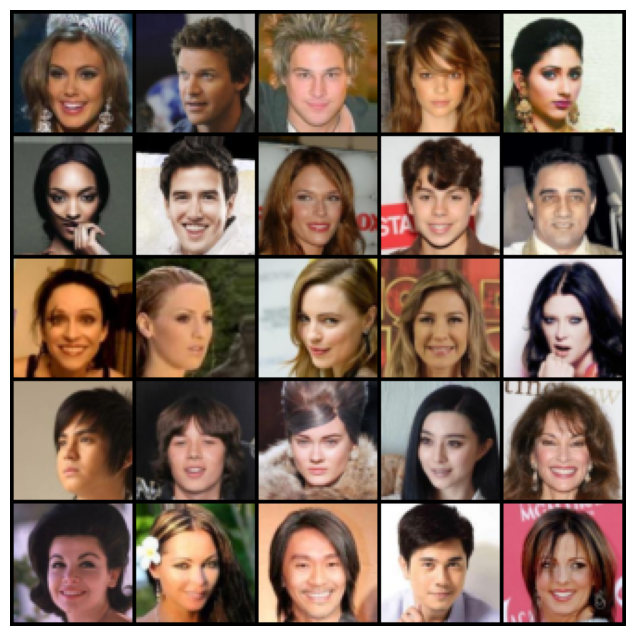

In [13]:
images, y = next(iter(train_loader))
images = (images * 0.5) + 0.5
grid = utils.make_grid(images[:25], nrow=5, padding=2)
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.show()

# WGAN

## Gradient Penalty

In [14]:
def gradient_penalty(critic, real, fake, device):
    B = real.size(0)
    eps = torch.rand(B, 1, 1, 1, device=device)
    x_hat = eps * real + (1 - eps) * fake
    x_hat.requires_grad_(True)

    scores = critic(x_hat)
    grad = torch.autograd.grad(
        outputs=scores,
        inputs=x_hat,
        grad_outputs=torch.ones_like(scores),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    grad = grad.view(B, -1)
    gp = ((grad.norm(2, dim=1) - 1) ** 2).mean()
    return gp

## Generator

In [15]:
class Generator(nn.Module):
    def __init__(self, z_dim=128, img_ch=3, base=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, base*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(base*8),
            nn.ReLU(True),

            nn.ConvTranspose2d(base*8, base*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base*4),
            nn.ReLU(True),

            nn.ConvTranspose2d(base*4, base*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base*2),
            nn.ReLU(True),

            nn.ConvTranspose2d(base*2, base, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base),
            nn.ReLU(True),

            nn.ConvTranspose2d(base, img_ch, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)

## Critic

In [16]:
class Critic(nn.Module):
    def __init__(self, img_ch=3, base=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(img_ch, base, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base, base*2, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base*2, base*4, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base*4, base*8, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base*8, 1, 4, 1, 0, bias=False),
        )

    def forward(self, x):
        return self.net(x).view(-1)

## Fréchet Inception Distance

In [17]:
def to_fid_uint8(x):
    x = ((x + 1) / 2).clamp(0, 1)
    return (x * 255).to(torch.uint8)

In [18]:
def make_fid(device):
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    return fid

In [19]:
@torch.no_grad()
def compute_fid(G, train_loader, fid, device, z_dim,
                fid_num_batches=50, gen_batches_for_fid=50, batch_size_for_fid=64):
    if fid is None:
        return None
    fid.reset()

    for i, batch in enumerate(train_loader):
        real = batch[0] if isinstance(batch, (list, tuple)) else batch
        real = real.to(device)
        fid.update(to_fid_uint8(real), real=True)
        if i + 1 >= fid_num_batches:
            break

    G.eval()
    for _ in range(gen_batches_for_fid):
        z = torch.randn(batch_size_for_fid, z_dim, 1, 1, device=device)
        fake = G(z)
        fid.update(to_fid_uint8(fake), real=False)
    G.train()

    return float(fid.compute().item())

## Plotting images, Saving model, Showing loss curves  

In [20]:
def save_grid(G, fixed_z, epoch, img_dir):
    G.eval()
    with torch.no_grad():
        fake = G(fixed_z)
        grid = make_grid(fake, nrow=5, padding=2, normalize=True, value_range=(-1, 1))
        path = os.path.join(img_dir, f"epoch_{epoch:04d}.png")
        save_image(grid, path)
    G.train()
    print(f"Saved sample grid: {path}")

In [21]:
def save_best_ckpt(path, epoch, G, D, optG, optD, best_fid, z_dim):
    torch.save({
        "epoch": epoch,
        "G_state": G.state_dict(),
        "D_state": D.state_dict(),
        "optG": optG.state_dict(),
        "optD": optD.state_dict(),
        "best_fid": best_fid,
        "z_dim": z_dim,
    }, path)

In [22]:
def plot_curves(out_dir, g_losses, d_losses, fid_epochs, fid_scores):
    plt.figure()
    plt.plot(g_losses, label="Generator loss")
    plt.plot(d_losses, label="Critic loss")
    plt.legend()
    plt.title("WGAN-GP Losses")
    plt.xlabel("Training step")
    plt.ylabel("Loss")
    plt.savefig(os.path.join(out_dir, "losses.png"), dpi=150)
    plt.show()

    if fid_scores is not None and len(fid_scores) > 0:
        plt.figure()
        plt.plot(fid_epochs, fid_scores, marker="o")
        plt.title("FID over epochs")
        plt.xlabel("Epoch")
        plt.ylabel("FID (lower is better)")
        plt.savefig(os.path.join(out_dir, "fid.png"), dpi=150)
        plt.show()

# Training

## Device

In [23]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


## Model, Optimizers, parameters

In [24]:
z_dim=128
lr=2e-4
betas=(0.0, 0.9)
n_critic=5
lambda_gp=10.0
max_epochs=30

## Train

### Train Critic

In [25]:
def train_critic(G, D, B, real, optD, z_dim, lambda_gp, device):
    z = torch.randn(B, z_dim, 1, 1, device=device)
    fake = G(z).detach()

    d_real = D(real).mean()
    d_fake = D(fake).mean()
    gp = gradient_penalty(D, real, fake, device)
    lossD = -(d_real - d_fake) + lambda_gp * gp

    optD.zero_grad(set_to_none=True)
    lossD.backward()
    optD.step()
    return lossD

### Train Generator

In [26]:
def train_generator(G, D, B, optG, z_dim, device):
    z = torch.randn(B, z_dim, 1, 1, device=device)
    fake = G(z)
    lossG = -D(fake).mean()

    optG.zero_grad(set_to_none=True)
    lossG.backward()
    optG.step()
    return lossG

## Train Loop

In [27]:
def train_wgan_gp_uncond(
    G,
    D,
    train_loader,
    device,
    img_dir,
    ckpt_dir,
    out_dir,
    optD,
    optG,
    n_critic=5,
    z_dim=128,
    lambda_gp=10.0,
    max_epochs=200,
    show_every=5,
    fid_every=5,
    fid_num_batches=50,
    gen_batches_for_fid=50,
    batch_size_for_fid=64,
    divergence_patience=4,
    divergence_margin=10.0,
):
    z_dim = int(z_dim)
    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(ckpt_dir, exist_ok=True)
    os.makedirs(out_dir, exist_ok=True)

    history = load_history(ckpt_dir)
    ckpt = try_load_latest_ckpt(G, D, optG, optD, ckpt_dir, device)

    if ckpt is None:
        set_global_seed(GLOBAL_SEED)
        fixed_z = torch.randn(25, z_dim, 1, 1, device=device)
        start_epoch = 1
        best_fid = float("inf")
        bad_fid_streak = 0
        save_grid(G, fixed_z, epoch=0, img_dir=img_dir)
    else:
        fixed_z = ckpt.get("fixed_z", None)
        if fixed_z is None:
            fixed_z = torch.randn(25, z_dim, 1, 1, device=device)
        else:
            fixed_z = fixed_z.to(device)
        start_epoch = int(ckpt.get("epoch", 0)) + 1
        best_fid = float(ckpt.get("best_fid", float("inf")))
        bad_fid_streak = int(ckpt.get("bad_fid_streak", 0))

    fid = make_fid(device)

    for epoch in range(start_epoch, max_epochs + 1):
        t0 = time.time()
        loader_iter = iter(train_loader)
        stop = False

        for _ in range(len(train_loader)):
            for _ in range(n_critic):
                try:
                    batch = next(loader_iter)
                except StopIteration:
                    loader_iter = iter(train_loader)
                    batch = next(loader_iter)

                real = batch[0] if isinstance(batch, (list, tuple)) else batch
                real = real.to(device)
                B = real.size(0)

                lossD = train_critic(G, D, B, real, optD, z_dim, lambda_gp, device)

            lossG = train_generator(G, D, B, optG, z_dim, device)

            history["d_losses"].append(float(lossD.item()))
            history["g_losses"].append(float(lossG.item()))

            if not (math.isfinite(history["d_losses"][-1]) and math.isfinite(history["g_losses"][-1])):
                print("🛑 Divergence detected (NaN/Inf loss). Stopping.")
                stop = True
                break

        print(
            f"Epoch {epoch}/{max_epochs}  "
            f"lossD={history['d_losses'][-1]:.4f}  lossG={history['g_losses'][-1]:.4f}  "
            f"time={time.time()-t0:.1f}s"
        )
        if stop:
            break

        if epoch % show_every == 0:
            save_grid(G, fixed_z, epoch, img_dir)

        if fid is not None and epoch % fid_every == 0:
            score = compute_fid(
                G, train_loader, fid, device, z_dim,
                fid_num_batches=fid_num_batches,
                gen_batches_for_fid=gen_batches_for_fid,
                batch_size_for_fid=batch_size_for_fid
            )
            history["fid_scores"].append(float(score))
            history["fid_epochs"].append(int(epoch))
            print(f"FID @ epoch {epoch}: {score:.3f}")

            if score < best_fid:
                best_fid = float(score)
                bad_fid_streak = 0
                ckpt_best = ckpt_paths(ckpt_dir)["best"]
                save_ckpt(ckpt_best, {
                    "epoch": epoch,
                    "G_state": G.state_dict(),
                    "D_state": D.state_dict(),
                    "optG": optG.state_dict(),
                    "optD": optD.state_dict(),
                    "best_fid": best_fid,
                    "bad_fid_streak": bad_fid_streak,
                    "z_dim": z_dim,
                    "fixed_z": fixed_z.detach().cpu(),
                    "rng_state": get_rng_state(),
                })
                print(f"✅ Saved BEST checkpoint (FID={best_fid:.3f}) -> {ckpt_best}")
            else:
                bad_fid_streak = bad_fid_streak + 1 if score > best_fid + divergence_margin else 0
                if bad_fid_streak >= divergence_patience:
                    print(f"🛑 Stopping: FID worsened by >{divergence_margin} for {divergence_patience} evals.")
                    break

        ckpt_last = ckpt_paths(ckpt_dir)["last"]
        save_ckpt(ckpt_last, {
            "epoch": epoch,
            "G_state": G.state_dict(),
            "D_state": D.state_dict(),
            "optG": optG.state_dict(),
            "optD": optD.state_dict(),
            "best_fid": best_fid,
            "bad_fid_streak": bad_fid_streak,
            "z_dim": z_dim,
            "fixed_z": fixed_z.detach().cpu(),
            "rng_state": get_rng_state(),
        })
        save_history(ckpt_dir, history)
        plot_curves(out_dir, history["g_losses"], history["d_losses"], history["fid_epochs"], history["fid_scores"])

    save_history(ckpt_dir, history)
    plot_curves(out_dir, history["g_losses"], history["d_losses"], history["fid_epochs"], history["fid_scores"])
    print("Done. Best FID:", best_fid)
    print("Best checkpoint:", ckpt_paths(ckpt_dir)["best"])
    print("Last checkpoint:", ckpt_paths(ckpt_dir)["last"])
    return G, D

Saved sample grid: wgan/samples/epoch_0000.png


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:02<00:00, 44.1MB/s]


Epoch 1/30  lossD=-6.5766  lossG=4.8507  time=517.8s


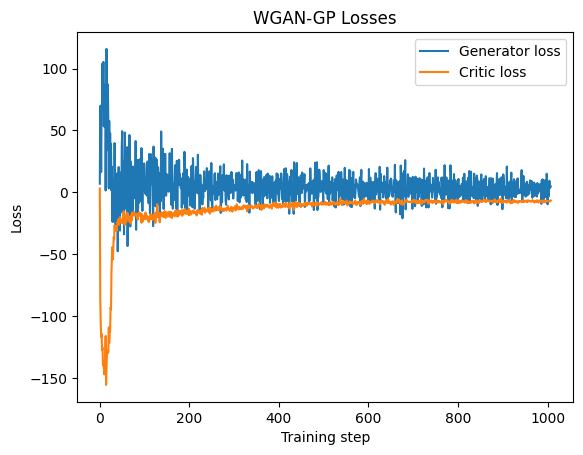

Epoch 2/30  lossD=-5.3337  lossG=-1.6975  time=401.9s


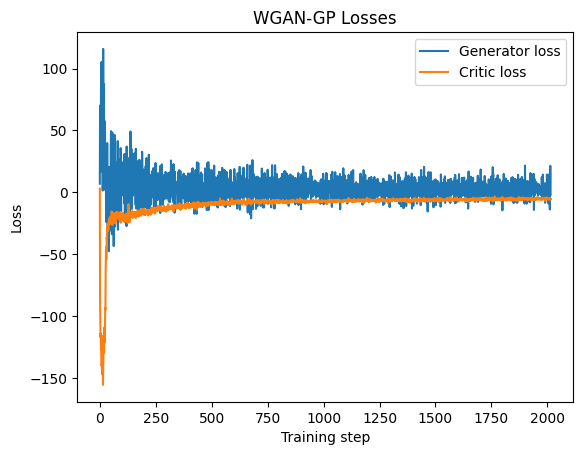

Epoch 3/30  lossD=-5.0469  lossG=-6.9715  time=401.9s


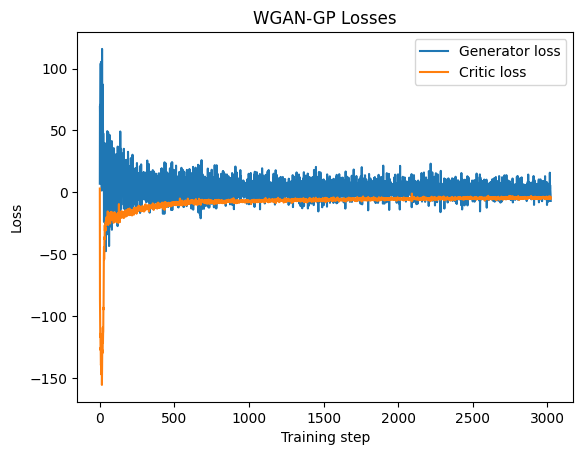

Epoch 4/30  lossD=-4.3411  lossG=9.3804  time=401.7s


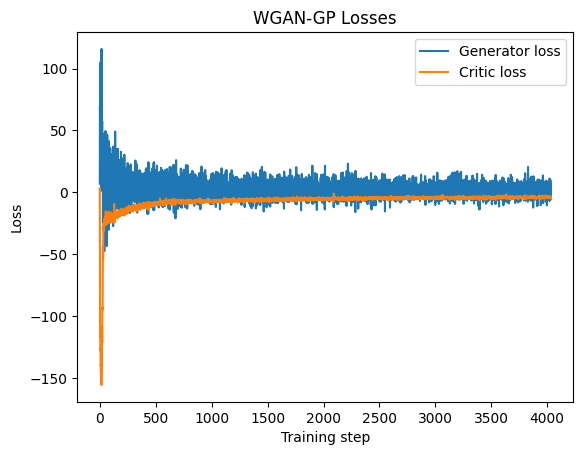

Epoch 5/30  lossD=-3.9073  lossG=-1.0851  time=404.7s
Saved sample grid: wgan/samples/epoch_0005.png
FID @ epoch 5: 81.812
✅ Saved BEST checkpoint (FID=81.812) -> wgan/checkpoints/best.pt


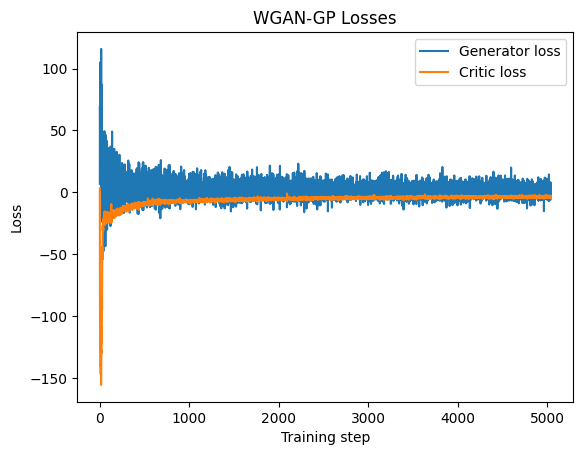

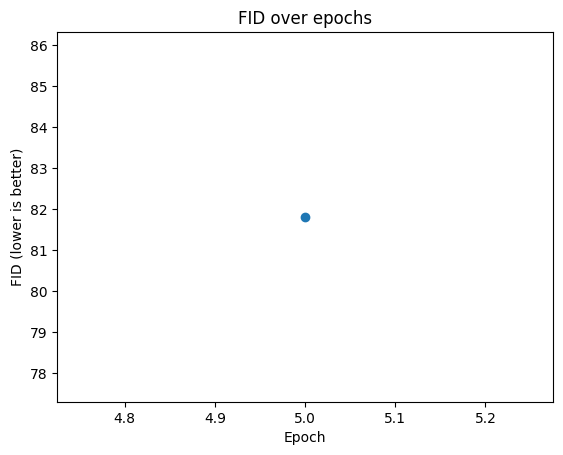

Epoch 6/30  lossD=-3.8717  lossG=-0.6601  time=401.3s


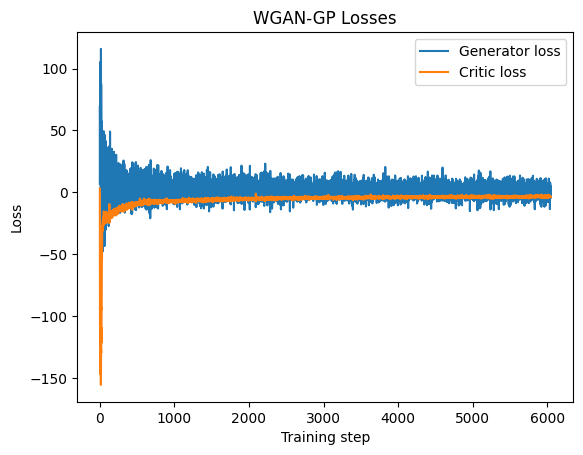

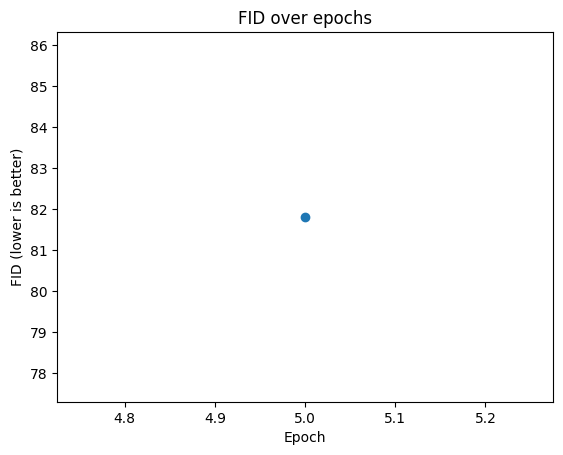

Epoch 7/30  lossD=-3.0154  lossG=-0.4400  time=401.0s


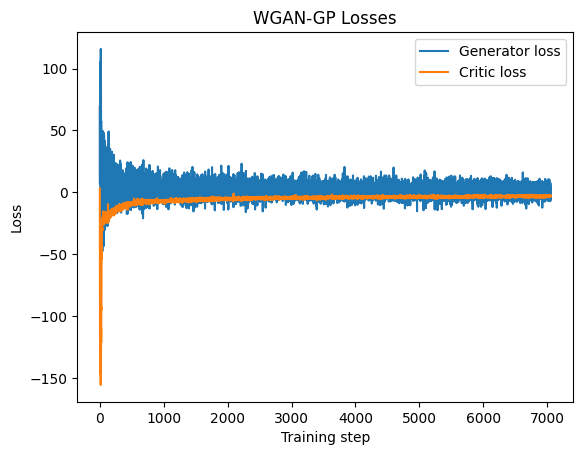

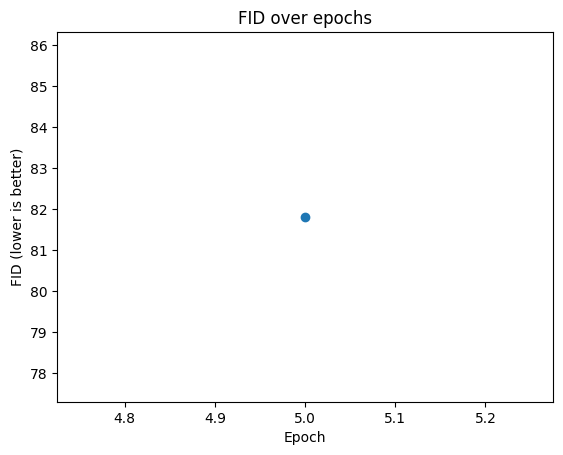

Epoch 8/30  lossD=-2.5252  lossG=-3.9344  time=401.2s


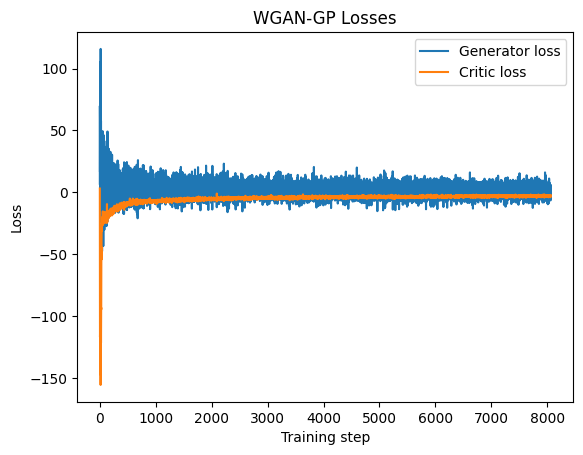

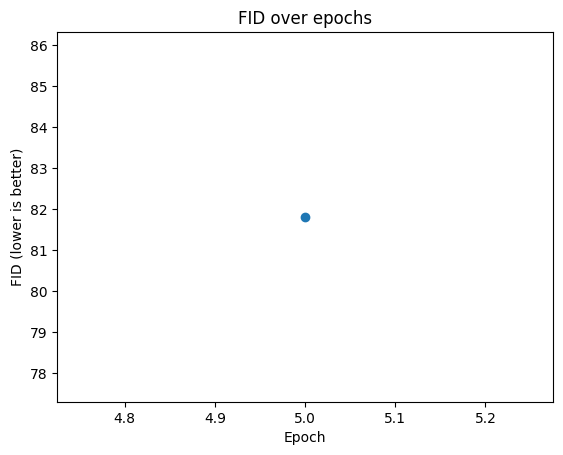

Epoch 9/30  lossD=-3.0962  lossG=2.5405  time=400.7s


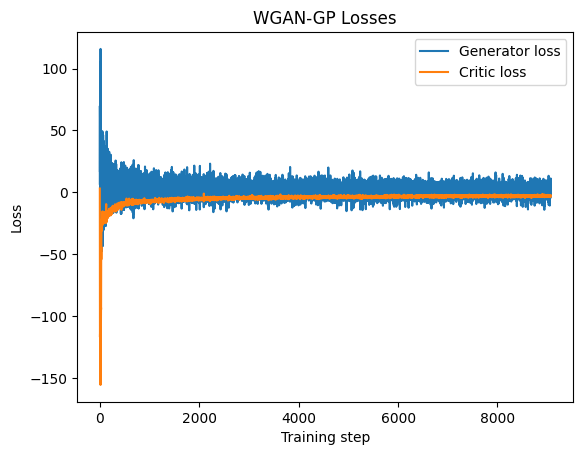

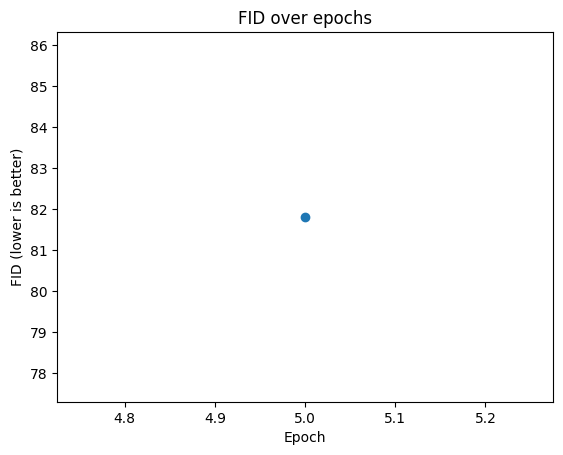

Epoch 10/30  lossD=-3.1653  lossG=-7.4365  time=400.6s
Saved sample grid: wgan/samples/epoch_0010.png
FID @ epoch 10: 48.060
✅ Saved BEST checkpoint (FID=48.060) -> wgan/checkpoints/best.pt


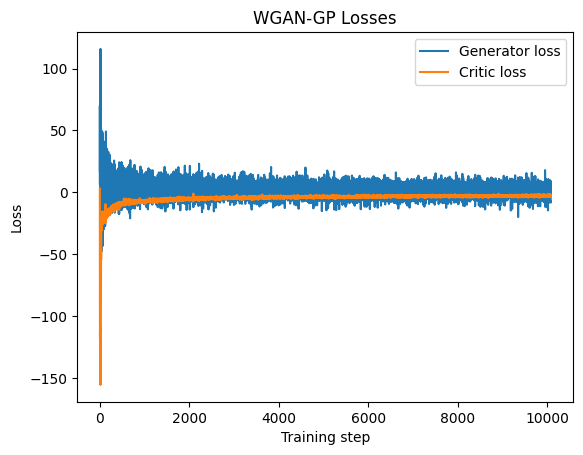

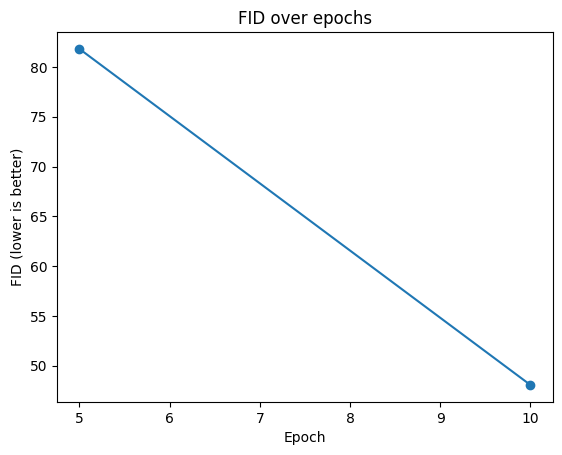

Epoch 11/30  lossD=-2.4110  lossG=-6.0614  time=400.7s


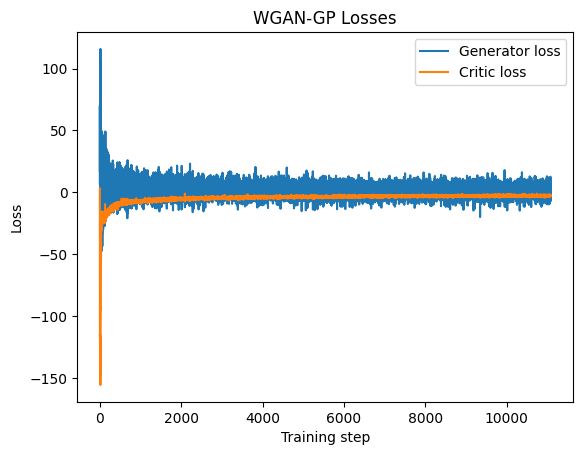

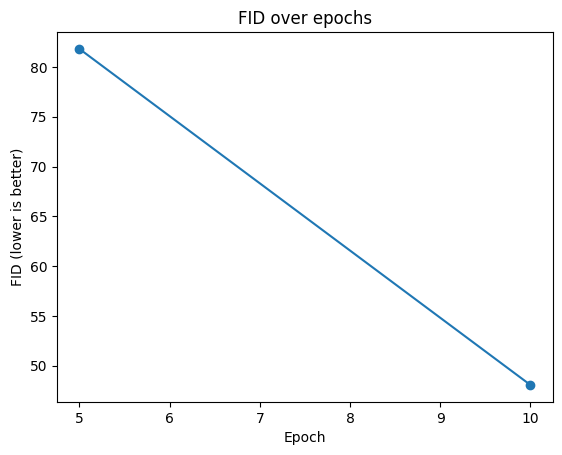

Epoch 12/30  lossD=-2.5958  lossG=-0.2202  time=400.6s


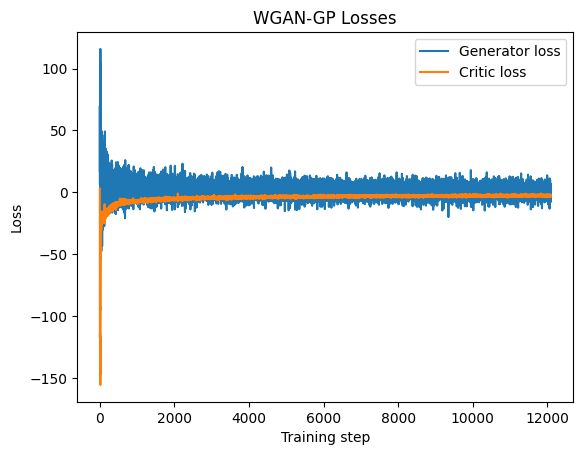

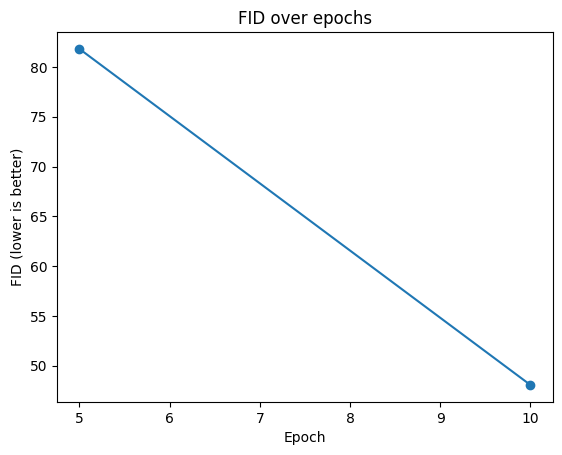

Epoch 13/30  lossD=-3.1775  lossG=-1.5478  time=400.5s


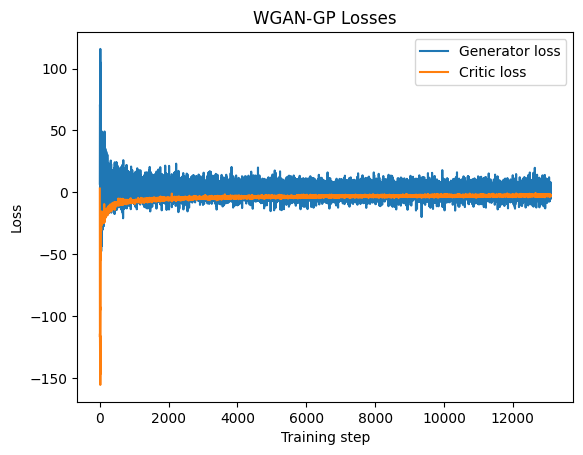

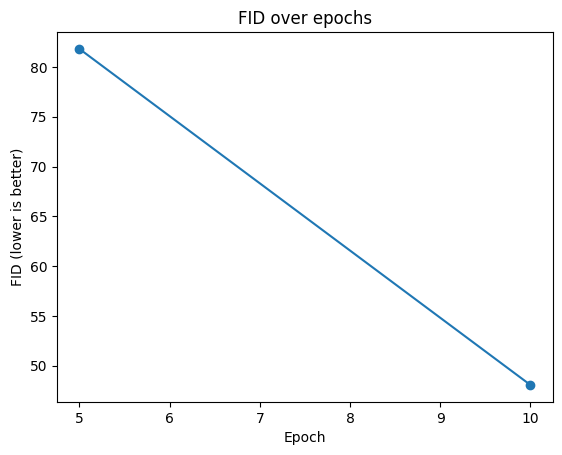

Epoch 14/30  lossD=-2.1335  lossG=-0.0989  time=400.5s


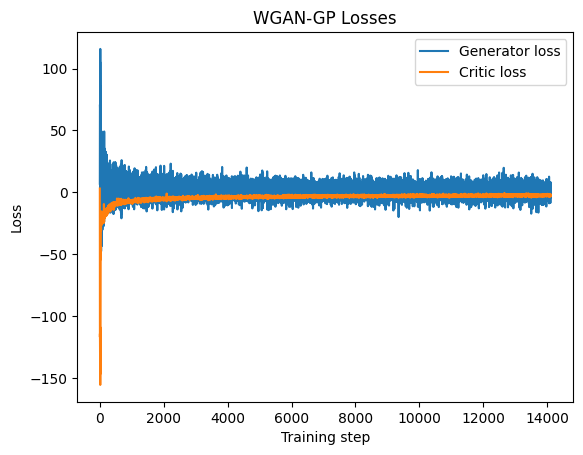

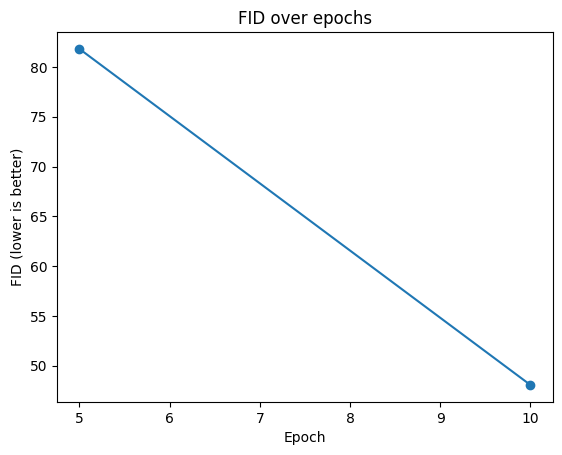

Epoch 15/30  lossD=-1.9691  lossG=5.5806  time=400.5s
Saved sample grid: wgan/samples/epoch_0015.png
FID @ epoch 15: 39.514
✅ Saved BEST checkpoint (FID=39.514) -> wgan/checkpoints/best.pt


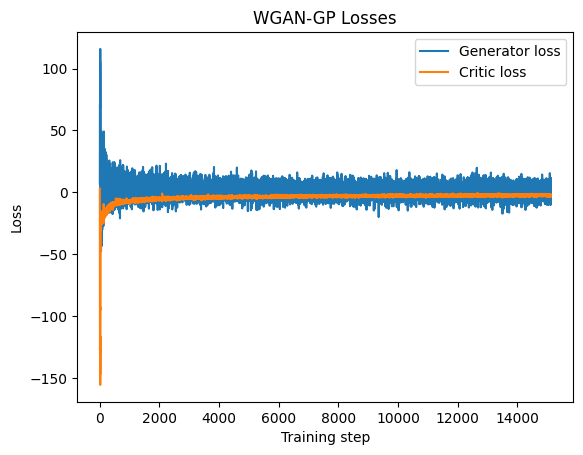

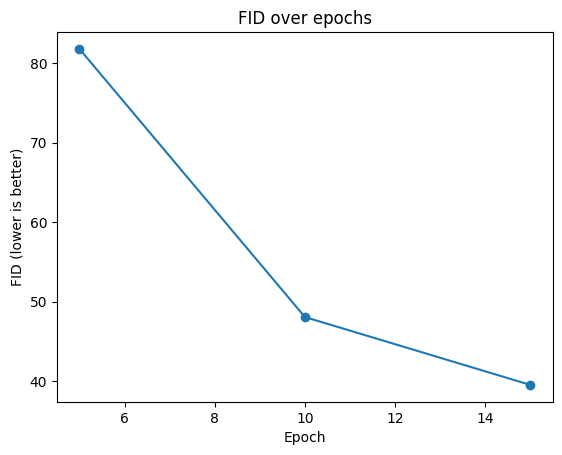

Epoch 16/30  lossD=-2.7797  lossG=3.3477  time=400.4s


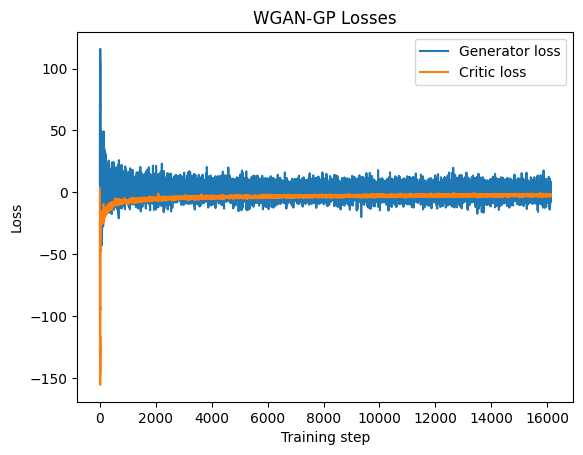

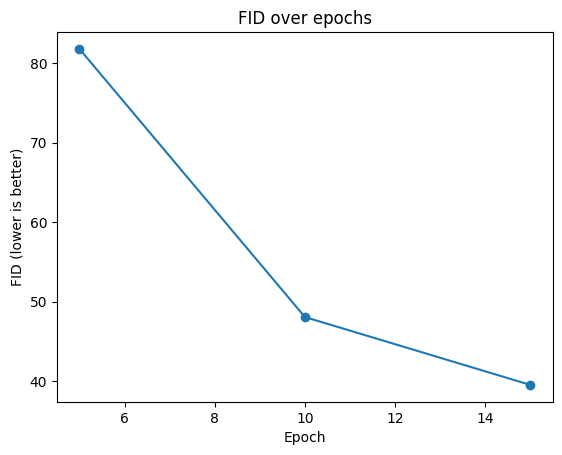

Epoch 17/30  lossD=-2.0238  lossG=-3.0710  time=401.2s


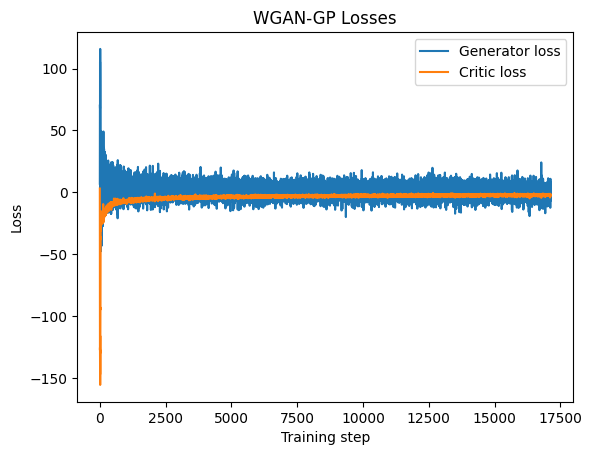

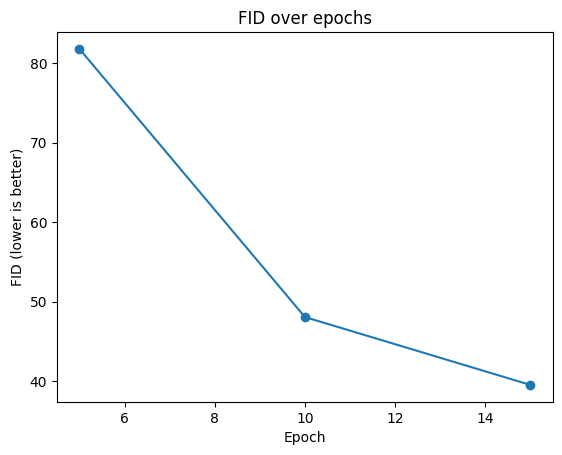

Epoch 18/30  lossD=-2.0905  lossG=1.6858  time=403.5s


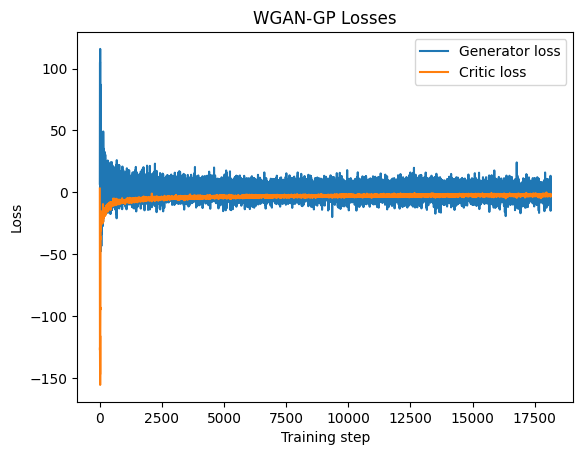

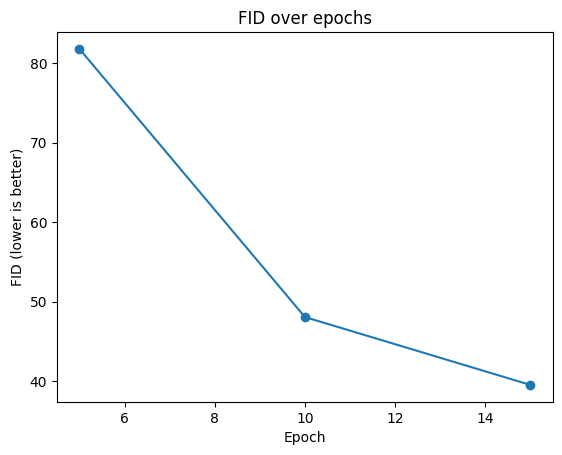

Epoch 19/30  lossD=-2.1113  lossG=-0.8696  time=400.5s


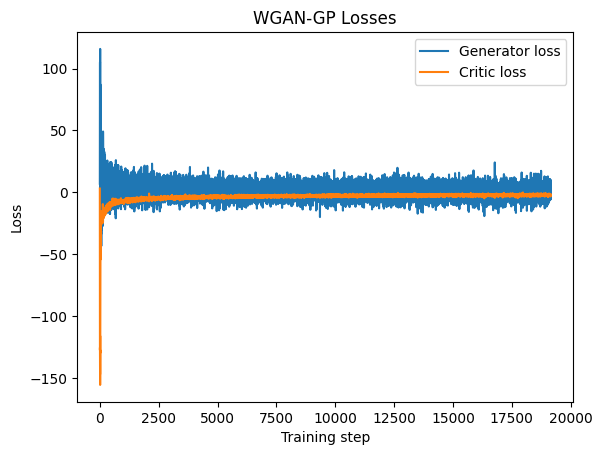

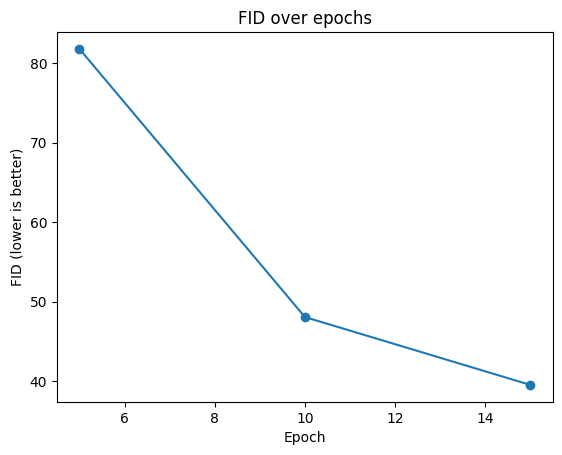

Epoch 20/30  lossD=-2.1470  lossG=1.1158  time=400.3s
Saved sample grid: wgan/samples/epoch_0020.png
FID @ epoch 20: 36.259
✅ Saved BEST checkpoint (FID=36.259) -> wgan/checkpoints/best.pt


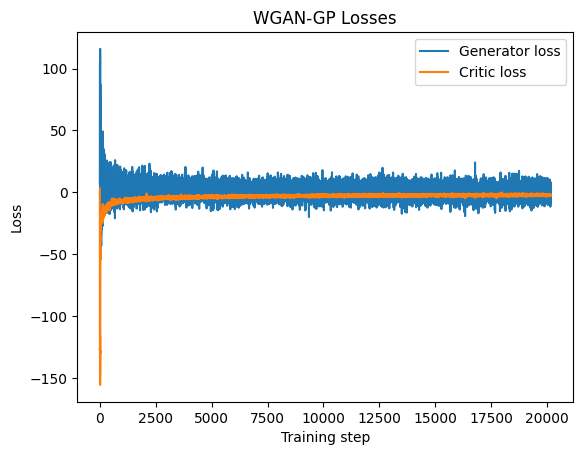

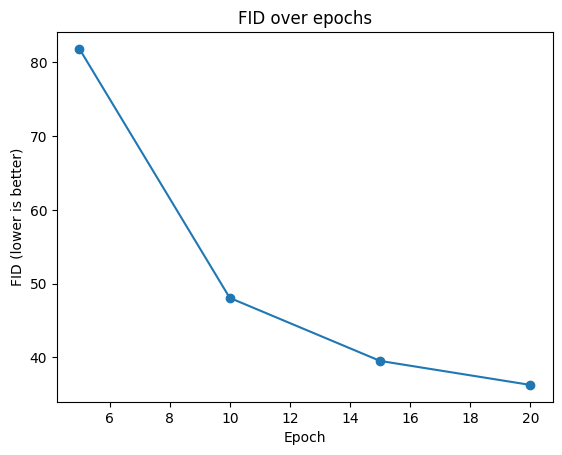

Epoch 21/30  lossD=-2.7976  lossG=4.3378  time=400.5s


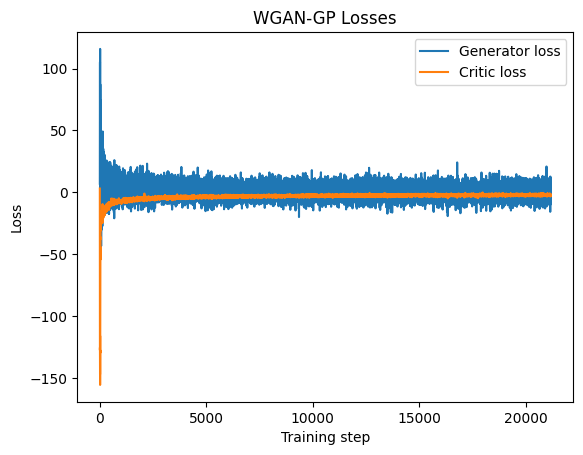

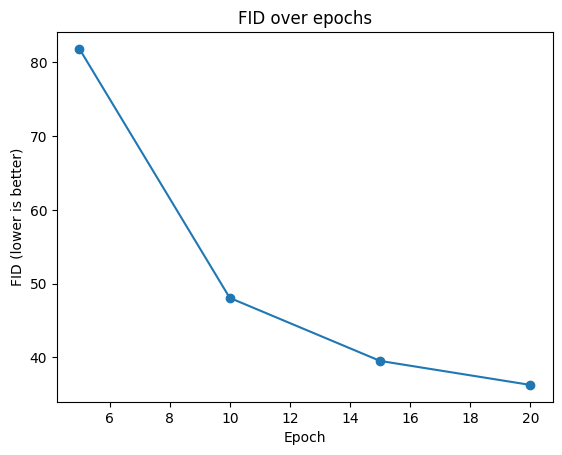

Epoch 22/30  lossD=-2.2307  lossG=-0.2581  time=400.5s


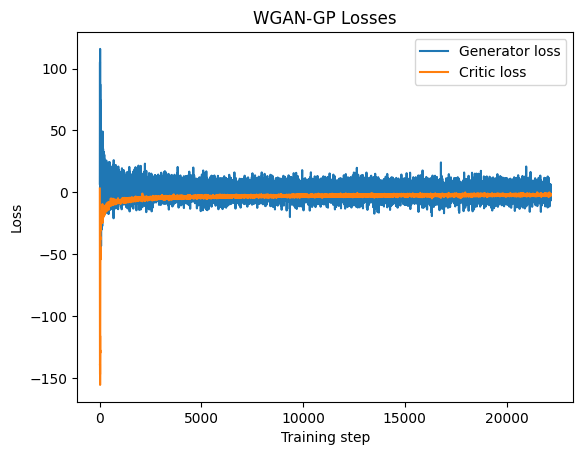

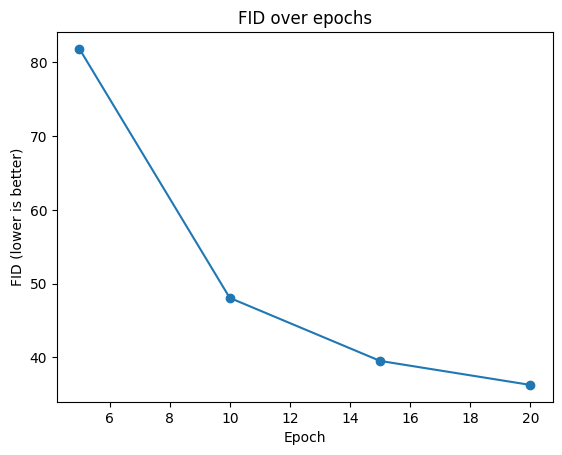

Epoch 23/30  lossD=-1.1488  lossG=2.3729  time=400.4s


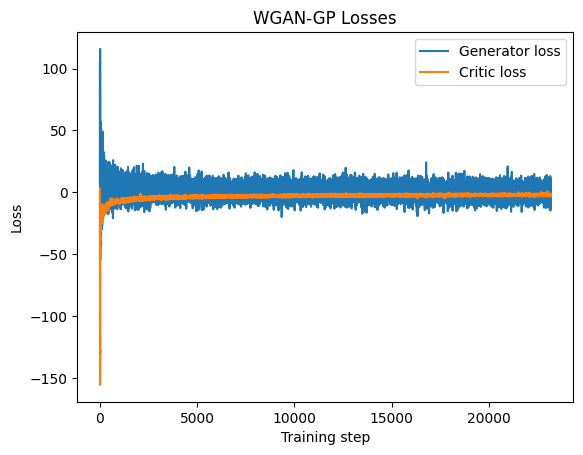

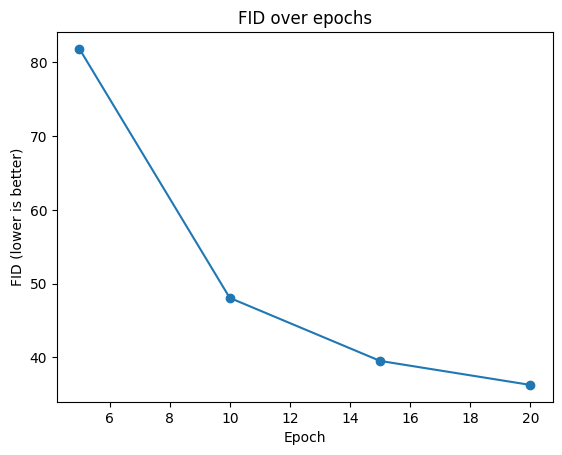

Epoch 24/30  lossD=-2.6019  lossG=-1.2120  time=400.4s


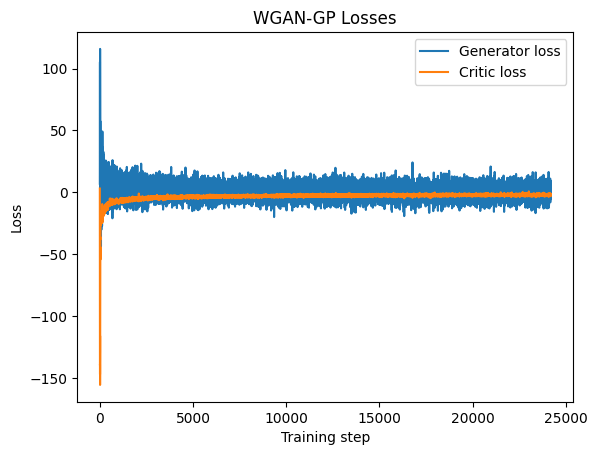

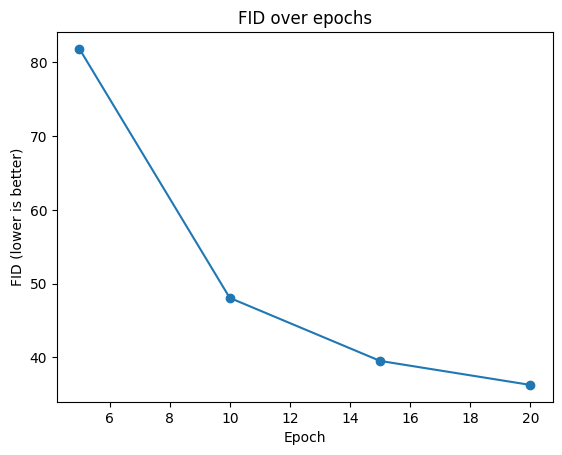

Epoch 25/30  lossD=-1.5947  lossG=-2.0662  time=401.4s
Saved sample grid: wgan/samples/epoch_0025.png
FID @ epoch 25: 31.202
✅ Saved BEST checkpoint (FID=31.202) -> wgan/checkpoints/best.pt


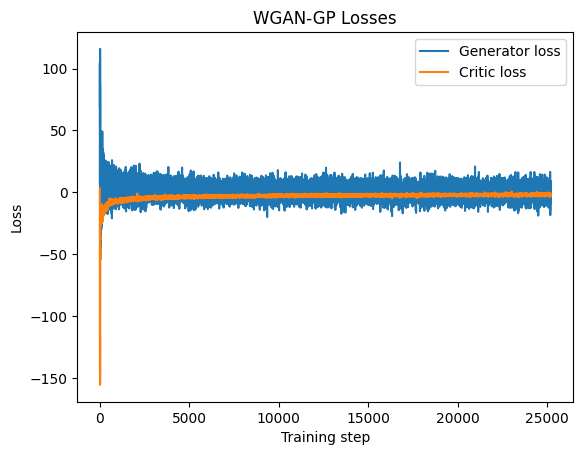

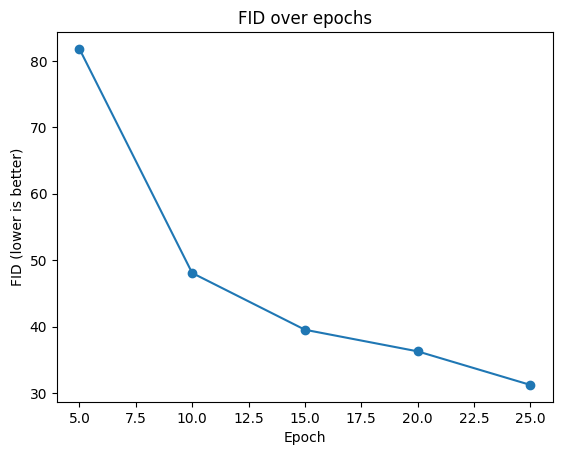

Epoch 26/30  lossD=-2.4884  lossG=-5.8735  time=400.5s


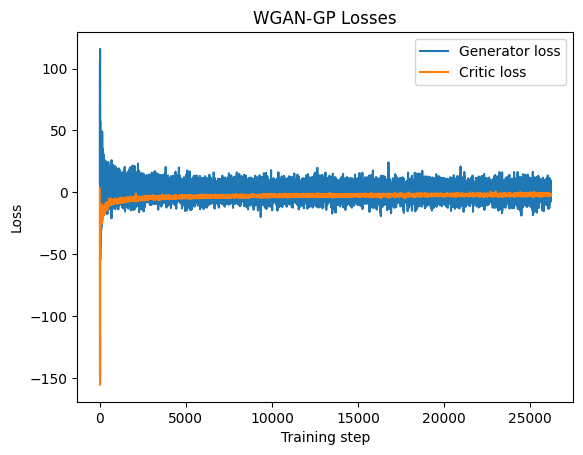

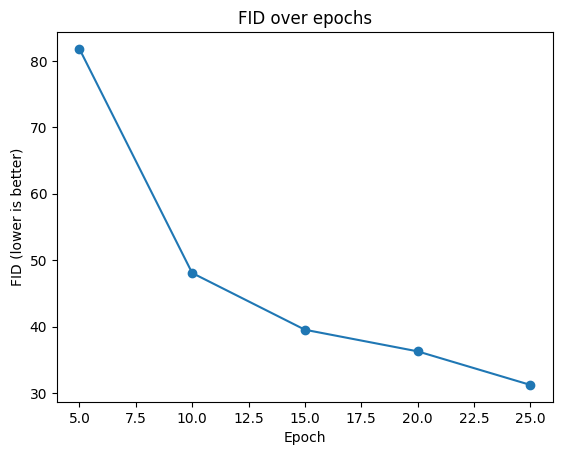

Epoch 27/30  lossD=-0.7495  lossG=11.0936  time=400.6s


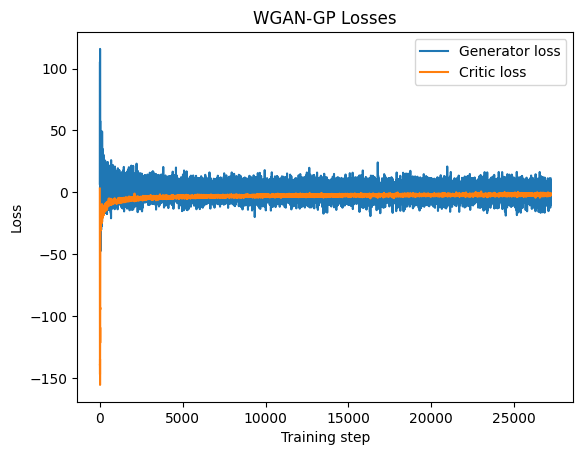

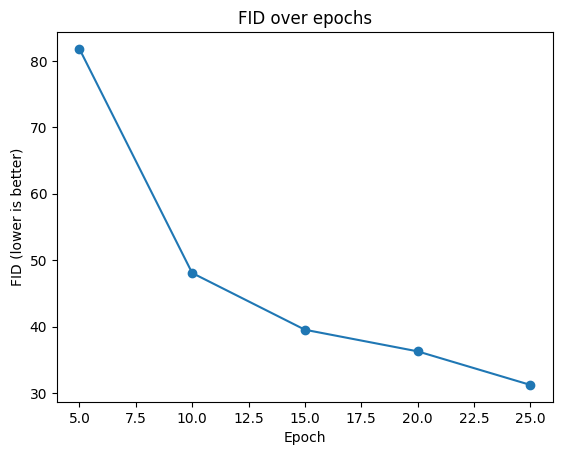

Epoch 28/30  lossD=-2.8340  lossG=6.7056  time=400.6s


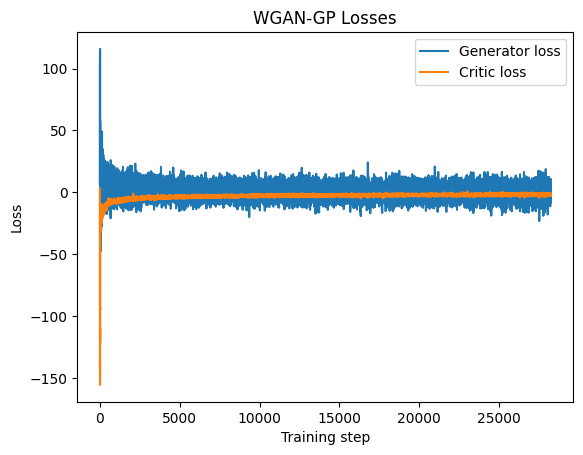

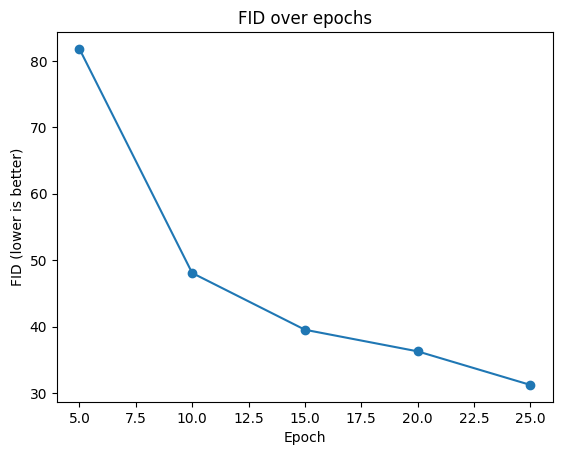

Epoch 29/30  lossD=-1.6094  lossG=10.7813  time=401.0s


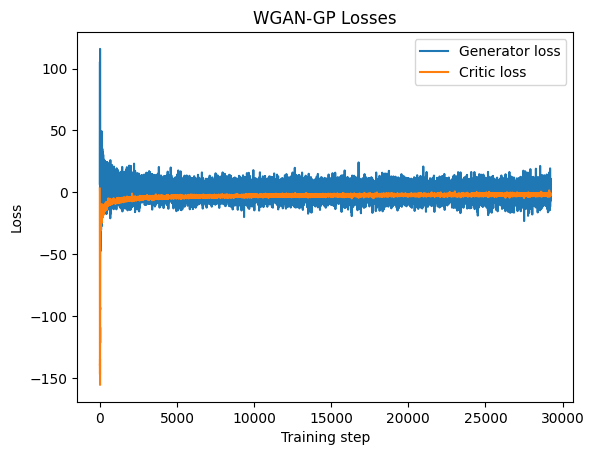

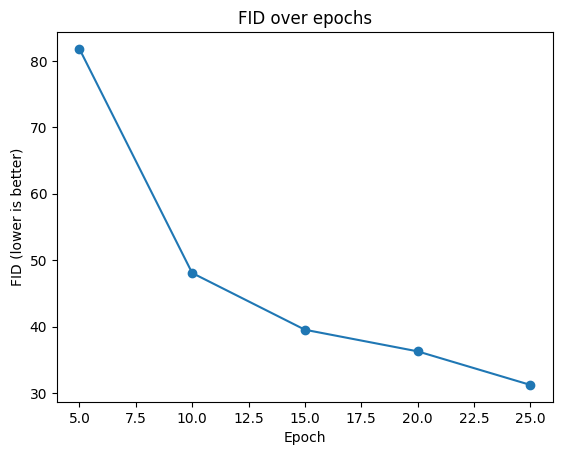

Epoch 30/30  lossD=-1.8345  lossG=-4.8660  time=401.2s
Saved sample grid: wgan/samples/epoch_0030.png
FID @ epoch 30: 30.469
✅ Saved BEST checkpoint (FID=30.469) -> wgan/checkpoints/best.pt


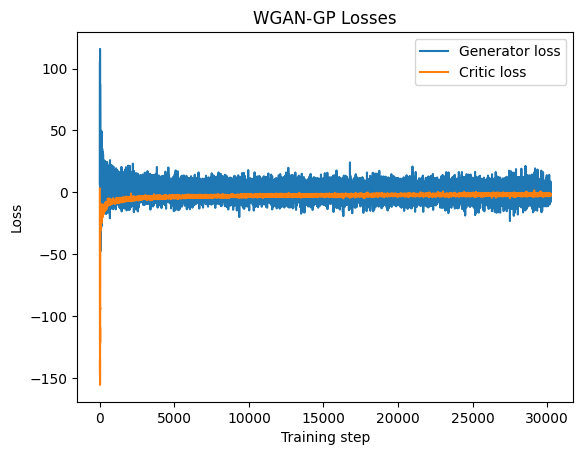

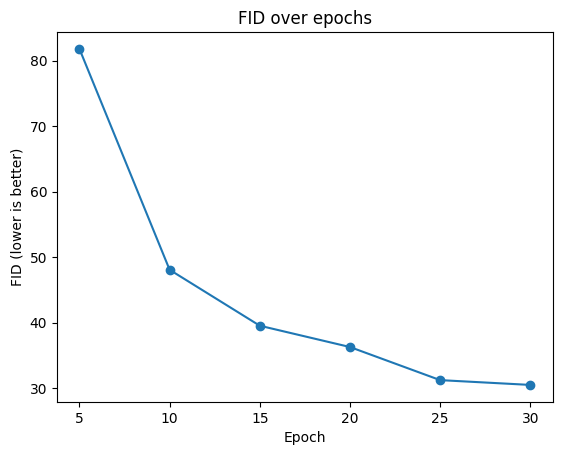

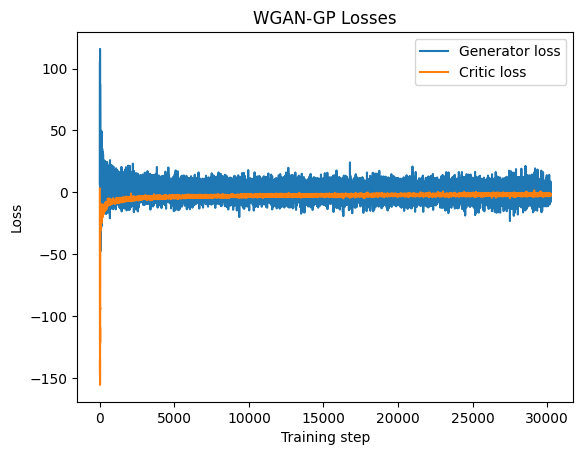

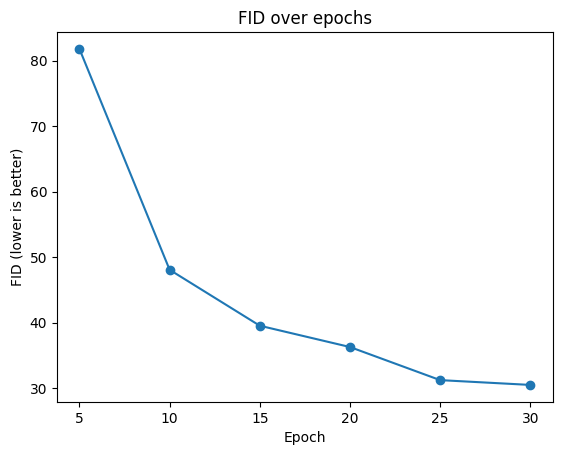

Done. Best FID: 30.469087600708008
Best checkpoint: wgan/checkpoints/best.pt
Last checkpoint: wgan/checkpoints/last.pt


In [28]:
if RUN_WGAN:
    out_dir = "wgan"
    os.makedirs(out_dir, exist_ok=True)
    img_dir = os.path.join(out_dir, "samples")
    ckpt_dir = os.path.join(out_dir, "checkpoints")
    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(ckpt_dir, exist_ok=True)

    G = Generator(z_dim=z_dim).to(device)
    D = Critic().to(device)
    optG = optim.Adam(G.parameters(), lr=lr, betas=betas)
    optD = optim.Adam(D.parameters(), lr=lr, betas=betas)

    train_wgan_gp_uncond(
        G=G, D=D,
        train_loader=train_loader,
        device=device,
        img_dir=img_dir,
        ckpt_dir=ckpt_dir,
        out_dir=out_dir,
        optD=optD,
        optG=optG,
        n_critic=n_critic,
        z_dim=z_dim,
        lambda_gp=lambda_gp,
        max_epochs=max_epochs,
    )
else:
    print("Skipping WGAN (RUN_WGAN=False)")

# PHASE 2

## Dataset

In [29]:
class CelebABlackBrownSmiling(Dataset):
    def __init__(self, root="/kaggle/input/datasets/jessicali9530/celeba-dataset", split="train", transform=None, seed=42):
        super().__init__()
        self.transform = transform
        self.img_dir = os.path.join(root, "img_align_celeba", "img_align_celeba")

        attrs = pd.read_csv(os.path.join(root, "list_attr_celeba.csv"))
        parts = pd.read_csv(os.path.join(root, "list_eval_partition.csv"))
        df = attrs.merge(parts, on="image_id")

        split_id = {"train": 0, "valid": 1, "test": 2}[split]
        df = df[df["partition"] == split_id].reset_index(drop=True)

        black = (df["Black_Hair"] == 1)
        brown = (df["Brown_Hair"] == 1)

        black_only = df.index[black & ~brown].to_numpy()
        brown_only = df.index[brown & ~black].to_numpy()

        g = torch.Generator().manual_seed(seed)
        n = int(min(len(black_only), len(brown_only)))

        black_sel = black_only[torch.randperm(len(black_only), generator=g)[:n].tolist()]
        brown_sel = brown_only[torch.randperm(len(brown_only), generator=g)[:n].tolist()]

        chosen = np.concatenate([black_sel, brown_sel])
        chosen = chosen[torch.randperm(len(chosen), generator=g).tolist()]

        self.df = df.loc[chosen].reset_index(drop=True)

        self.total_black = int((self.df["Black_Hair"] == 1).sum())
        self.total_brown = int((self.df["Brown_Hair"] == 1).sum())
        self.total_smile = int((self.df["Smiling"] == 1).sum())

    def __len__(self): return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(os.path.join(self.img_dir, row["image_id"])).convert("RGB")
        if self.transform: img = self.transform(img)

        c = torch.tensor([
            1.0 if row["Black_Hair"] == 1 else 0.0,
            1.0 if row["Brown_Hair"] == 1 else 0.0,
            1.0 if row["Smiling"] == 1 else 0.0,
        ], dtype=torch.float32)
        return img, c

# Train data

In [30]:
kaggle_root = "/kaggle/input/datasets/jessicali9530/celeba-dataset"

train_dataset = CelebABlackBrownSmiling(
    root=kaggle_root,
    split="train",
    transform=transform,
    seed=42
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    drop_last=True
)

## Statistics

In [31]:
print("Dataset size:", len(train_dataset))
print("Total Brown positives:", train_dataset.total_brown)
print("Total Black positives:", train_dataset.total_black)
print("Total Smiling positives:", train_dataset.total_smile)
print("Equal:", train_dataset.total_brown == train_dataset.total_black)

Dataset size: 64522
Total Brown positives: 32261
Total Black positives: 32261
Total Smiling positives: 31584
Equal: True


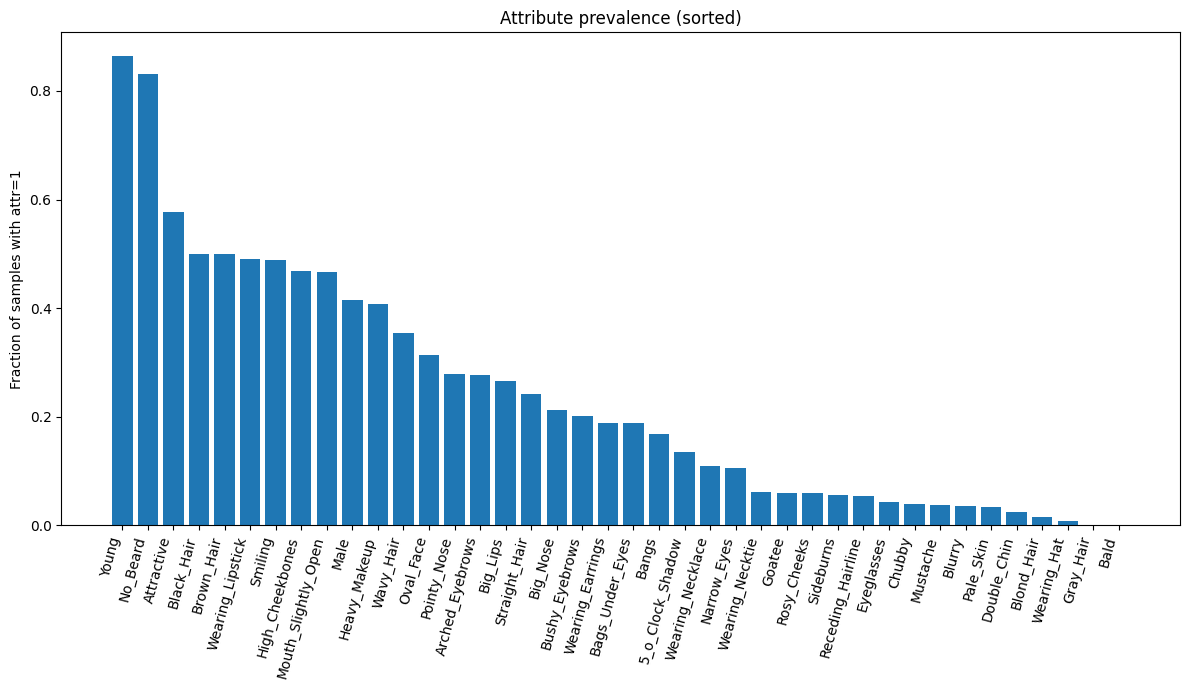

In [32]:
attr_cols = [c for c in train_dataset.df.columns if c not in ["image_id", "partition"]]

A = train_dataset.df[attr_cols].to_numpy()
A01 = (A == 1).astype(np.float32)

pos_rate = A01.mean(axis=0)
pos_count = A01.sum(axis=0).astype(int)
names = attr_cols

order = np.argsort(pos_rate)[::-1]
pos_rate_sorted = pos_rate[order]
names_sorted = [names[i] for i in order]

plt.figure(figsize=(12, 7))
plt.bar(range(len(names_sorted)), pos_rate_sorted)
plt.xticks(range(len(names_sorted)), names_sorted, rotation=75, ha="right")
plt.ylabel("Fraction of samples with attr=1")
plt.title("Attribute prevalence (sorted)")
plt.tight_layout()
plt.show()

# Plotting images

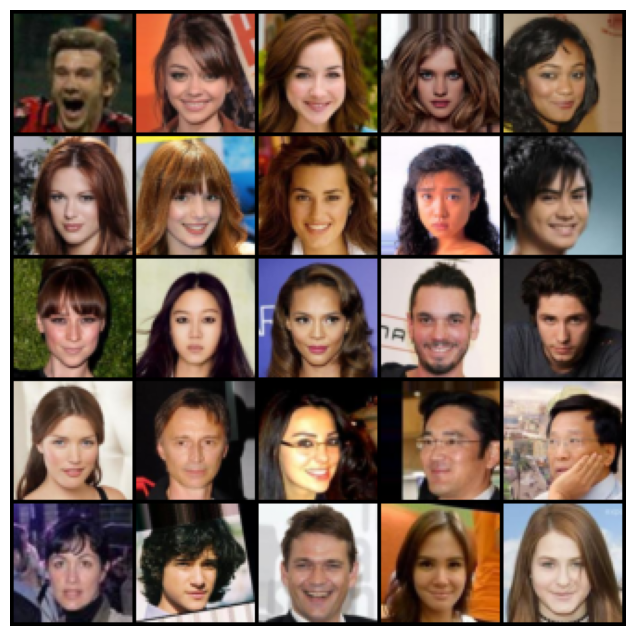

In [33]:
images, c = next(iter(train_loader))
images = (images * 0.5) + 0.5
grid = utils.make_grid(images[:25], nrow=5, padding=2)
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.show()

## Gradient Penalty

In [34]:
def gradient_penalty(critic, real, fake, c, device):
    B = real.size(0)
    eps = torch.rand(B, 1, 1, 1, device=device)
    x_hat = eps * real + (1 - eps) * fake
    x_hat.requires_grad_(True)

    scores = critic(x_hat, c)
    grad = torch.autograd.grad(
        outputs=scores,
        inputs=x_hat,
        grad_outputs=torch.ones_like(scores),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    grad = grad.view(B, -1)
    gp = ((grad.norm(2, dim=1) - 1) ** 2).mean()
    return gp

# Generator Concat

In [35]:
class Generator_Concat(nn.Module):
    def __init__(self, z_dim=128, c_dim=3, img_ch=3, base=64):
        super().__init__()
        in_dim = z_dim + c_dim
        self.net = nn.Sequential(
            nn.ConvTranspose2d(in_dim, base*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(base*8),
            nn.ReLU(True),

            nn.ConvTranspose2d(base*8, base*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base*4),
            nn.ReLU(True),

            nn.ConvTranspose2d(base*4, base*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base*2),
            nn.ReLU(True),

            nn.ConvTranspose2d(base*2, base, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base),
            nn.ReLU(True),

            nn.ConvTranspose2d(base, img_ch, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z, c):
        c = c.view(c.size(0), c.size(1), 1, 1)
        x = torch.cat([z, c], dim=1)
        return self.net(x)

# Critic Concat

In [36]:
class Critic_Concat(nn.Module):
    def __init__(self, c_dim=3, img_ch=3, base=64):
        super().__init__()
        self.c_dim = c_dim
        in_ch = img_ch + c_dim
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, base, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base, base*2, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base*2, base*4, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base*4, base*8, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base*8, 1, 4, 1, 0, bias=False),
        )

    def forward(self, x, c):
        B, _, H, W = x.shape
        c_map = c.view(B, self.c_dim, 1, 1).expand(B, self.c_dim, H, W)
        x2 = torch.cat([x, c_map], dim=1)
        return self.net(x2).view(-1)

# Generator Inject

In [37]:
class FiLM(nn.Module):
    def __init__(self, c_dim, n_channels):
        super().__init__()
        self.to_gb = nn.Sequential(
            nn.Linear(c_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 2 * n_channels),
        )

    def forward(self, h, c):
        gb = self.to_gb(c)
        gamma, beta = gb.chunk(2, dim=1)
        gamma = gamma.view(-1, h.size(1), 1, 1)
        beta  = beta.view(-1, h.size(1), 1, 1)
        return (1 + gamma) * h + beta


class GeneratorFiLM(nn.Module):
    def __init__(self, z_dim=128, c_dim=3, img_ch=3, base=64):
        super().__init__()
        self.deconv1 = nn.ConvTranspose2d(z_dim, base*8, 4, 1, 0, bias=False)
        self.bn1 = nn.BatchNorm2d(base*8); self.film1 = FiLM(c_dim, base*8)

        self.deconv2 = nn.ConvTranspose2d(base*8, base*4, 4, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(base*4); self.film2 = FiLM(c_dim, base*4)

        self.deconv3 = nn.ConvTranspose2d(base*4, base*2, 4, 2, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(base*2); self.film3 = FiLM(c_dim, base*2)

        self.deconv4 = nn.ConvTranspose2d(base*2, base, 4, 2, 1, bias=False)
        self.bn4 = nn.BatchNorm2d(base); self.film4 = FiLM(c_dim, base)

        self.deconv5 = nn.ConvTranspose2d(base, img_ch, 4, 2, 1, bias=False)

        self.act = nn.ReLU(True)
        self.tanh = nn.Tanh()

    def forward(self, z, c):
        h = self.deconv1(z); h = self.bn1(h); h = self.film1(h, c); h = self.act(h)
        h = self.deconv2(h); h = self.bn2(h); h = self.film2(h, c); h = self.act(h)
        h = self.deconv3(h); h = self.bn3(h); h = self.film3(h, c); h = self.act(h)
        h = self.deconv4(h); h = self.bn4(h); h = self.film4(h, c); h = self.act(h)
        h = self.deconv5(h)
        return self.tanh(h)

# Critic Inject

In [ ]:
class CriticProj(nn.Module):
    def __init__(self, c_dim=3, img_ch=3, base=64):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(img_ch, base, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base, base*2, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base*2, base*4, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base*4, base*8, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.lin = nn.Linear(base*8, 1)

        self.embed = nn.Sequential(
            nn.Linear(c_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, base*8),
        )

    def forward(self, x, c):
        h = self.features(x)
        h = self.pool(h).view(x.size(0), -1)
        out = self.lin(h).view(-1)

        e = self.embed(c)
        
        proj = (h * e).sum(dim=1)

        return out + proj

## Fréchet Inception Distance

In [39]:
@torch.no_grad()
def compute_fid(G, train_loader, fid, device, z_dim,
                fid_num_batches=50, gen_batches_for_fid=50):
    if fid is None:
        return None
    fid.reset()

    for i, (real, _) in enumerate(train_loader):
        real = real.to(device)
        fid.update(to_fid_uint8(real), real=True)
        if i + 1 >= fid_num_batches:
            break

    G.eval()
    loader_iter = iter(train_loader)
    for _ in range(gen_batches_for_fid):
        try:
            _, c = next(loader_iter)
        except StopIteration:
            loader_iter = iter(train_loader)
            _, c = next(loader_iter)

        c = c.to(device).float()
        B = c.size(0)
        z = torch.randn(B, int(z_dim), 1, 1, device=device)
        fake = G(z, c)
        fid.update(to_fid_uint8(fake), real=False)
    G.train()

    return float(fid.compute().item())

# Plotting Images

In [40]:
def save_grid(G, fixed_z, epoch, img_dir, device):
    G.eval()
    with torch.no_grad():
        c_list = [
            [1,0,0],
            [1,0,1],
            [0,1,0],
            [0,1,1],
        ]
        k = 5

        assert fixed_z.size(0) >= len(c_list) * k

        imgs = []
        for j, c0 in enumerate(c_list):
            z = fixed_z[j*k:(j+1)*k]
            c = torch.tensor(c0, dtype=torch.float32, device=device).view(1, 3).repeat(k, 1)
            fake = G(z, c)
            imgs.append(fake)

        fake_all = torch.cat(imgs, dim=0)
        grid = make_grid(fake_all, nrow=k, padding=2, normalize=True, value_range=(-1, 1))
        path = os.path.join(img_dir, f"epoch_{epoch:04d}_cond.png")
        save_image(grid, path)

    G.train()
    print(f"Saved sample grid: {path}")

# Train

## Train critic

In [41]:
def train_critic(G, D, real, c, optD, z_dim, lambda_gp, device):
    B = real.size(0)
    z = torch.randn(B, int(z_dim), 1, 1, device=device)
    fake = G(z, c).detach()

    d_real = D(real, c).mean()
    d_fake = D(fake, c).mean()
    gp = gradient_penalty(D, real, fake, c, device)

    lossD = -(d_real - d_fake) + lambda_gp * gp

    optD.zero_grad(set_to_none=True)
    lossD.backward()
    optD.step()
    return lossD

## Train generator

In [42]:
def train_generator(G, D, c, optG, z_dim, device):
    B = c.size(0)
    z = torch.randn(B, int(z_dim), 1, 1, device=device)
    fake = G(z, c)

    lossG = -D(fake, c).mean()

    optG.zero_grad(set_to_none=True)
    lossG.backward()
    optG.step()
    return lossG

# Train Loop

In [43]:
def train_wgan_gp_cond(
    G,
    D,
    train_loader,
    device,
    img_dir,
    ckpt_dir,
    out_dir,
    optD,
    optG,
    n_critic=5,
    z_dim=128,
    lambda_gp=10.0,
    max_epochs=200,
    show_every=5,
    fid_every=5,
    fid_num_batches=50,
    gen_batches_for_fid=50,
    divergence_patience=4,
    divergence_margin=10.0,
):
    z_dim = int(z_dim)
    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(ckpt_dir, exist_ok=True)
    os.makedirs(out_dir, exist_ok=True)

    history = load_history(ckpt_dir)
    ckpt = try_load_latest_ckpt(G, D, optG, optD, ckpt_dir, device)

    if ckpt is None:
        set_global_seed(GLOBAL_SEED)
        fixed_z = torch.randn(20, z_dim, 1, 1, device=device)
        start_epoch = 1
        best_fid = float("inf")
        bad_fid_streak = 0
        save_grid(G, fixed_z, epoch=0, img_dir=img_dir, device=device)
    else:
        fixed_z = ckpt.get("fixed_z", None)
        if fixed_z is None:
            fixed_z = torch.randn(20, z_dim, 1, 1, device=device)
        else:
            fixed_z = fixed_z.to(device)
        start_epoch = int(ckpt.get("epoch", 0)) + 1
        best_fid = float(ckpt.get("best_fid", float("inf")))
        bad_fid_streak = int(ckpt.get("bad_fid_streak", 0))

    fid = make_fid(device)

    for epoch in range(start_epoch, max_epochs + 1):
        t0 = time.time()
        loader_iter = iter(train_loader)
        stop = False

        for _ in range(len(train_loader)):
            for _ in range(n_critic):
                try:
                    real, c = next(loader_iter)
                except StopIteration:
                    loader_iter = iter(train_loader)
                    real, c = next(loader_iter)

                real = real.to(device)
                c = c.to(device).float()

                lossD = train_critic(G, D, real, c, optD, z_dim, lambda_gp, device)

            lossG = train_generator(G, D, c, optG, z_dim, device)

            history["d_losses"].append(float(lossD.item()))
            history["g_losses"].append(float(lossG.item()))

            if not (math.isfinite(history["d_losses"][-1]) and math.isfinite(history["g_losses"][-1])):
                print("🛑 Divergence detected (NaN/Inf loss). Stopping.")
                stop = True
                break

        print(
            f"Epoch {epoch}/{max_epochs}  "
            f"lossD={history['d_losses'][-1]:.4f}  lossG={history['g_losses'][-1]:.4f}  "
            f"time={time.time()-t0:.1f}s"
        )
        if stop:
            break

        if epoch % show_every == 0:
            save_grid(G, fixed_z, epoch, img_dir, device)

        if fid is not None and epoch % fid_every == 0:
            score = compute_fid(
                G, train_loader, fid, device, z_dim,
                fid_num_batches=fid_num_batches,
                gen_batches_for_fid=gen_batches_for_fid,
            )
            history["fid_scores"].append(float(score))
            history["fid_epochs"].append(int(epoch))
            print(f"FID @ epoch {epoch}: {score:.3f}")

            if score < best_fid:
                best_fid = float(score)
                bad_fid_streak = 0
                ckpt_best = ckpt_paths(ckpt_dir)["best"]
                save_ckpt(ckpt_best, {
                    "epoch": epoch,
                    "G_state": G.state_dict(),
                    "D_state": D.state_dict(),
                    "optG": optG.state_dict(),
                    "optD": optD.state_dict(),
                    "best_fid": best_fid,
                    "bad_fid_streak": bad_fid_streak,
                    "z_dim": z_dim,
                    "fixed_z": fixed_z.detach().cpu(),
                    "rng_state": get_rng_state(),
                })
                print(f"✅ Saved BEST checkpoint (FID={best_fid:.3f}) -> {ckpt_best}")
            else:
                bad_fid_streak = bad_fid_streak + 1 if score > best_fid + divergence_margin else 0
                if bad_fid_streak >= divergence_patience:
                    print(f"🛑 Stopping: FID worsened by >{divergence_margin} for {divergence_patience} evals.")
                    break

        ckpt_last = ckpt_paths(ckpt_dir)["last"]
        save_ckpt(ckpt_last, {
            "epoch": epoch,
            "G_state": G.state_dict(),
            "D_state": D.state_dict(),
            "optG": optG.state_dict(),
            "optD": optD.state_dict(),
            "best_fid": best_fid,
            "bad_fid_streak": bad_fid_streak,
            "z_dim": z_dim,
            "fixed_z": fixed_z.detach().cpu(),
            "rng_state": get_rng_state(),
        })
        save_history(ckpt_dir, history)
        plot_curves(out_dir, history["g_losses"], history["d_losses"], history["fid_epochs"], history["fid_scores"])

    save_history(ckpt_dir, history)
    plot_curves(out_dir, history["g_losses"], history["d_losses"], history["fid_epochs"], history["fid_scores"])
    print("Done. Best FID:", best_fid)
    print("Best checkpoint:", ckpt_paths(ckpt_dir)["best"])
    print("Last checkpoint:", ckpt_paths(ckpt_dir)["last"])
    return G, D

In [44]:
if RUN_WGAN_CONCAT:
    out_dir = "wgan_concat"
    os.makedirs(out_dir, exist_ok=True)
    img_dir = os.path.join(out_dir, "samples")
    ckpt_dir = os.path.join(out_dir, "checkpoints")
    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(ckpt_dir, exist_ok=True)

    c_dim = 3
    G = Generator_Concat(z_dim=z_dim, c_dim=c_dim).to(device)
    D = Critic_Concat(c_dim=c_dim).to(device)
    optG = optim.Adam(G.parameters(), lr=lr, betas=betas)
    optD = optim.Adam(D.parameters(), lr=lr, betas=betas)

    train_wgan_gp_cond(
        G=G, D=D,
        train_loader=train_loader,
        device=device,
        img_dir=img_dir,
        ckpt_dir=ckpt_dir,
        out_dir=out_dir,
        optD=optD,
        optG=optG,
        n_critic=n_critic,
        z_dim=z_dim,
        lambda_gp=lambda_gp,
        max_epochs=max_epochs,
    )
else:
    print("Skipping WGAN_CONCAT (RUN_WGAN_CONCAT=False)")


Skipping WGAN_CONCAT (RUN_WGAN_CONCAT=False)


In [45]:
if RUN_WGAN_INJECT:
    out_dir = "wgan_inject"
    os.makedirs(out_dir, exist_ok=True)
    img_dir = os.path.join(out_dir, "samples")
    ckpt_dir = os.path.join(out_dir, "checkpoints")
    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(ckpt_dir, exist_ok=True)

    c_dim = 3
    G = GeneratorFiLM(z_dim=z_dim, c_dim=c_dim).to(device)
    D = CriticProj(c_dim=c_dim).to(device)
    optG = optim.Adam(G.parameters(), lr=lr, betas=betas)
    optD = optim.Adam(D.parameters(), lr=lr, betas=betas)

    train_wgan_gp_cond(
        G=G, D=D,
        train_loader=train_loader,
        device=device,
        img_dir=img_dir,
        ckpt_dir=ckpt_dir,
        out_dir=out_dir,
        optD=optD,
        optG=optG,
        n_critic=n_critic,
        z_dim=z_dim,
        lambda_gp=lambda_gp,
        max_epochs=max_epochs,
    )
else:
    print("Skipping WGAN_INJECT (RUN_WGAN_INJECT=False)")


Skipping WGAN_INJECT (RUN_WGAN_INJECT=False)


# Conditioned Data

In [ ]:
@torch.no_grad()
def load_best_G_and_controlled_samples(
    ckpt_path="Results/wgan_inject/checkpoints/best.pt",
    out_dir="Results/controlled_samples",
    seed=123
):
    os.makedirs(out_dir, exist_ok=True)

    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

    c_dim = 3
    z_dim_loaded = int(ckpt["z_dim"])

    G = GeneratorFiLM(z_dim=z_dim_loaded, c_dim=c_dim).to(device)
    G.load_state_dict(ckpt["G_state"])
    G.eval()

    torch.manual_seed(seed)
    z = torch.randn(10, z_dim_loaded, 1, 1, device=device)

    c1 = torch.tensor([1.0, 0.0, 0.0], device=device).view(1, 3).repeat(10, 1)
    c2 = torch.tensor([0.0, 0.0, 0.0], device=device).view(1, 3).repeat(10, 1)

    x1 = G(z, c1)
    x2 = G(z, c2)

    p1 = os.path.join(out_dir, "scenario1_black_hair_1_same_z.png")
    p2 = os.path.join(out_dir, "scenario2_brown_hair_0_same_z.png")
    p3 = os.path.join(out_dir, "side_by_side_same_z.png")

    save_image(make_grid(x1, nrow=5, normalize=True, value_range=(-1, 1)), p1)
    save_image(make_grid(x2, nrow=5, normalize=True, value_range=(-1, 1)), p2)
    save_image(make_grid(torch.cat([x1, x2], dim=0), nrow=5, normalize=True, value_range=(-1, 1)), p3)

    print("Loaded:", ckpt_path, "| epoch:", ckpt.get("epoch"), "| best_fid:", ckpt.get("best_fid"))
    print("Saved:", p1)
    print("Saved:", p2)
    print("Saved:", p3)

load_best_G_and_controlled_samples()

# Latent Interpolation

In [ ]:
@torch.no_grad()
def latent_interpolation_best_G(
    ckpt_path="Results/wgan_inject/checkpoints/best.pt",
    out_dir="Results/latent_interpolation",
    seed=123,
    steps=11,
    c_fixed=None
):
    os.makedirs(out_dir, exist_ok=True)

    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

    c_dim = 3
    z_dim_loaded = int(ckpt["z_dim"])

    G = GeneratorFiLM(z_dim=z_dim_loaded, c_dim=c_dim).to(device)
    G.load_state_dict(ckpt["G_state"])
    G.eval()

    if c_fixed is None:
        c_fixed = torch.tensor([0.0, 0.0, 0.0], device=device)
    c = c_fixed.view(1, c_dim).repeat(steps, 1)

    torch.manual_seed(seed)
    z_a = torch.randn(1, z_dim_loaded, 1, 1, device=device)
    z_b = torch.randn(1, z_dim_loaded, 1, 1, device=device)

    ts = torch.linspace(0, 1, steps, device=device).view(steps, 1, 1, 1)
    z = (1 - ts) * z_a + ts * z_b

    x = G(z, c)

    grid = make_grid(x, nrow=steps, normalize=True, value_range=(-1, 1))
    out_path = os.path.join(out_dir, f"latent_interp_steps{steps}.png")
    save_image(grid, out_path)

    print("Loaded:", ckpt_path, "| epoch:", ckpt.get("epoch"), "| best_fid:", ckpt.get("best_fid"))
    print("Saved interpolation grid:", out_path)

latent_interpolation_best_G()

# Entanglement Analysis

In [ ]:
@torch.no_grad()
def load_best_G_inject(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    z_dim_loaded = int(ckpt["z_dim"])
    G = GeneratorFiLM(z_dim=z_dim_loaded, c_dim=3).to(device)
    G.load_state_dict(ckpt["G_state"])
    G.eval()
    return G, z_dim_loaded, ckpt

@torch.no_grad()
def entanglement_analysis(
    ckpt_path="Results/wgan_inject/checkpoints/best.pt",
    out_dir="Results/entanglement",
    seed=123,
    n=10,
):
    os.makedirs(out_dir, exist_ok=True)

    G, z_dim_loaded, ckpt = load_best_G_inject(ckpt_path)

    torch.manual_seed(seed)
    z = torch.randn(n, z_dim_loaded, 1, 1, device=device)

    def save_compare(cond_a, cond_b, name_a, name_b, filename):
        cA = torch.tensor(cond_a, device=device).view(1, 3).repeat(n, 1)
        cB = torch.tensor(cond_b, device=device).view(1, 3).repeat(n, 1)

        xA = G(z, cA)
        xB = G(z, cB)

        grid = make_grid(torch.cat([xA, xB], dim=0), nrow=5, normalize=True, value_range=(-1, 1))
        path = os.path.join(out_dir, filename)
        save_image(grid, path)

        print(f"Saved: {path}")
        print(f"  Top:    {name_a}  c={cond_a}")
        print(f"  Bottom: {name_b}  c={cond_b}")

    save_compare(
        cond_a=[1.0, 0.0, 0.0],
        cond_b=[1.0, 0.0, 1.0],
        name_a="Black hair + Smiling=0",
        name_b="Black hair + Smiling=1",
        filename="hair_fixed_black_toggle_smile.png"
    )

    save_compare(
        cond_a=[1.0, 0.0, 0.0],
        cond_b=[0.0, 1.0, 0.0],
        name_a="Smiling=0 + Black hair",
        name_b="Smiling=0 + Brown hair",
        filename="smile_fixed0_toggle_hair.png"
    )

    save_compare(
        cond_a=[0.0, 0.0, 0.0],
        cond_b=[0.0, 0.0, 1.0],
        name_a="Non-brown hair + Smiling=0",
        name_b="Non-brown hair + Smiling=1",
        filename="hair_fixed_nonbrown_toggle_smile.png"
    )

    print("Loaded:", ckpt_path, "| epoch:", ckpt.get("epoch"), "| best_fid:", ckpt.get("best_fid"))

entanglement_analysis()